# Bước 7: So sánh hiệu năng các mô hình

Notebook này so sánh hiệu năng của 3 mô hình đã huấn luyện: **Random Forest**, **XGBoost** và **LightGBM** trên tập dữ liệu kiểm thử độc lập.

## 1. Import thư viện

In [7]:
import os
import re
import warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Imported libraries successfully.")

Imported libraries successfully.


## 2. Nạp dữ liệu kiểm thử

In [8]:
data_path = 'data/processed/Student_Performance_processed.csv'
for _ in range(5):
    if os.path.exists(data_path):
        break
    data_path = os.path.join('..', data_path)

df_encoded = pd.read_csv(data_path)

objective_features = [
    'age', 'study_hours', 'attendance_percentage',
    'math_score', 'science_score', 'english_score',
    'school_type', 'internet_access', 'extra_activities',
    'parent_education',
    'gender_male', 'gender_female', 'gender_other',
    'travel_time_<15 min', 'travel_time_15-30 min', 'travel_time_30-60 min', 'travel_time_>60 min',
    'study_method_notes', 'study_method_textbook', 'study_method_group study',
    'study_method_coaching', 'study_method_mixed', 'study_method_online videos'
]

df_encoded['study_hours_x_attendance'] = df_encoded['study_hours'] * df_encoded['attendance_percentage']
df_encoded['study_hours_squared'] = df_encoded['study_hours'] ** 2
df_encoded['attendance_squared'] = df_encoded['attendance_percentage'] ** 2

subject_score_features = ['math_score', 'science_score', 'english_score']
df_encoded['subject_score_mean'] = df_encoded[subject_score_features].mean(axis=1)
df_encoded['subject_score_min'] = df_encoded[subject_score_features].min(axis=1)
df_encoded['subject_score_max'] = df_encoded[subject_score_features].max(axis=1)
df_encoded['subject_score_range'] = df_encoded['subject_score_max'] - df_encoded['subject_score_min']
df_encoded['subject_score_std'] = df_encoded[subject_score_features].std(axis=1)

X_raw = df_encoded[objective_features + ['study_hours_x_attendance', 'study_hours_squared', 'attendance_squared']]
y = df_encoded['final_grade']

_, X_test_raw, _, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set size: {X_test_raw.shape[0]} samples.")

Test set size: 5000 samples.


## 3. Nạp các mô hình đã lưu

In [9]:
models_dir = 'models'
for _ in range(5):
    if os.path.exists(models_dir):
        break
    models_dir = os.path.join('..', models_dir)

rf_path = os.path.join(models_dir, 'random_forest_model.pkl')
xgb_path = os.path.join(models_dir, 'xgboost_model.pkl')
lgb_path = os.path.join(models_dir, 'lightgbm_model.pkl')
encoder_path = os.path.join(models_dir, 'label_encoder_xgboost.pkl')

rf_model = joblib.load(rf_path)
xgb_model = joblib.load(xgb_path)
lgb_model = joblib.load(lgb_path)
label_encoder = joblib.load(encoder_path)

print("Loaded all models successfully.")

Loaded all models successfully.


## 4. Chuẩn bị tập Test riêng cho từng mô hình và Dự đoán

In [10]:
# 4.1. Random Forest
X_test_rf = X_test_raw.copy()
y_pred_rf = rf_model.predict(X_test_rf)

# 4.2. XGBoost (cần làm sạch tên cột đặc trưng)
X_test_xgb = X_test_raw.copy()
sanitized_features = []
seen = {}
for col in X_test_xgb.columns:
    s = re.sub(r'[^0-9a-zA-Z_]', '_', col)
    if s in seen:
        seen[s] += 1
        s = f"{s}_{seen[s]}"
    else:
        seen[s] = 0
    sanitized_features.append(s)

X_test_xgb.columns = sanitized_features
y_pred_xgb_encoded = xgb_model.predict(X_test_xgb)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# 4.3. LightGBM (cần thêm các đặc trưng thống kê điểm số)
_, X_test_lgb, _, _ = train_test_split(
    df_encoded, y, test_size=0.2, random_state=42, stratify=y
)
X_test_lgb['study_hours_x_attendance'] = X_test_lgb['study_hours'] * X_test_lgb['attendance_percentage']
X_test_lgb['study_hours_squared'] = X_test_lgb['study_hours'] ** 2
X_test_lgb['attendance_squared'] = X_test_lgb['attendance_percentage'] ** 2
X_test_lgb['subject_score_mean'] = X_test_lgb[subject_score_features].mean(axis=1)
X_test_lgb['subject_score_min'] = X_test_lgb[subject_score_features].min(axis=1)
X_test_lgb['subject_score_max'] = X_test_lgb[subject_score_features].max(axis=1)
X_test_lgb['subject_score_range'] = X_test_lgb['subject_score_max'] - X_test_lgb['subject_score_min']
X_test_lgb['subject_score_std'] = X_test_lgb[subject_score_features].std(axis=1)

lgb_features = objective_features + [
    'study_hours_x_attendance', 'study_hours_squared', 'attendance_squared',
    'subject_score_mean', 'subject_score_min', 'subject_score_max', 'subject_score_range', 'subject_score_std'
]
X_test_lgb = X_test_lgb[lgb_features]
y_pred_lgb = lgb_model.predict(X_test_lgb)

print("Completed predictions for all models.")

Completed predictions for all models.


## 5. Tính toán các chỉ số đánh giá

In [11]:
metrics = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_lgb, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted'),
        f1_score(y_test, y_pred_lgb, average='weighted')
    ]
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))

        Model  Accuracy  Macro F1  Weighted F1
Random Forest    0.8536  0.853262     0.853688
      XGBoost    0.8330  0.824652     0.832963
     LightGBM    0.8154  0.816588     0.815395


## 6. Trực quan hóa so sánh

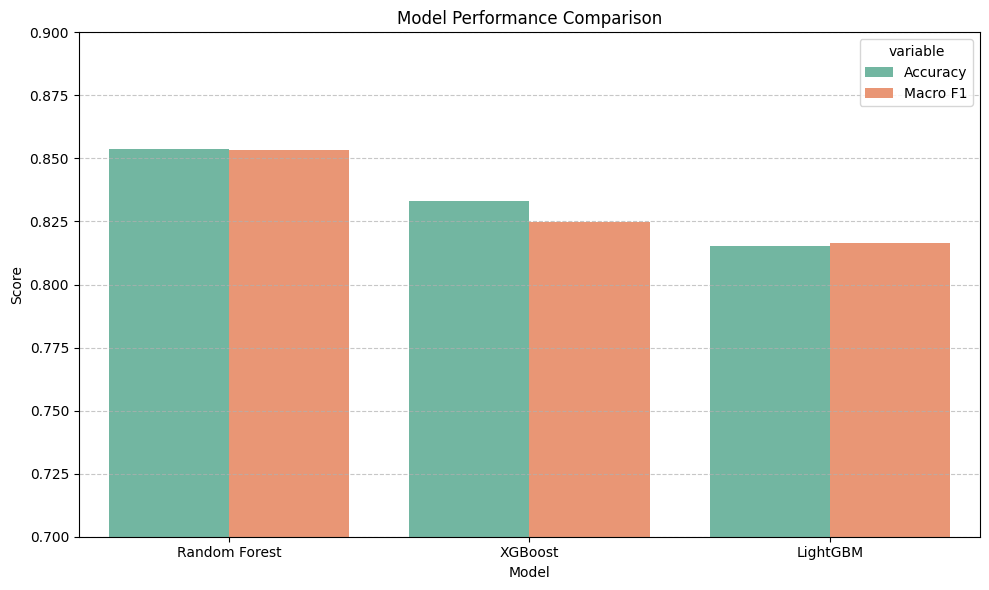

In [12]:
df_melted = pd.melt(df_metrics, id_vars='Model', value_vars=['Accuracy', 'Macro F1'])
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='value', hue='variable', palette='Set2')
plt.ylim(0.7, 0.9)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

results_dir = 'results'
for _ in range(5):
    if os.path.exists(results_dir):
        break
    results_dir = os.path.join('..', results_dir)

plt.savefig(os.path.join(results_dir, 'model_comparison.png'), dpi=150)
plt.show()